# Problem 2 — When to use which scaler?

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

আমাদের কাছে তিনটি feature আছে:

| Feature | বিবরণ |
|---|---|
| `Monthly_Income` (BDT) | কিছু মানুষের income অত্যন্ত বেশি — **outlier** আছে |
| `Room_Temperature_C` | মান শুধু **18 থেকে 30**-এর মধ্যে — সুন্দর, bounded range |
| `Transaction_Count_Last_7_Days` | অনেক মান **0**, কিছু মানুষ অনেক বেশি transaction করে — **outlier** আছে |

আমাদের দুটো কাজ করতে হবে:
1. প্রতিটি feature-এর জন্য সবচেয়ে উপযুক্ত **scaler** বেছে নেওয়া এবং কারণ ব্যাখ্যা করা।
2. একটি সংক্ষিপ্ত **numeric example** দিয়ে দেখানো কেন সেই scaler নিরাপদ বা বেশি interpretable।


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- বাস্তব data-তে **outlier** আছে কিনা সেটা চিনতে পারব।
- outlier-এর উপস্থিতি অনুযায়ী **সঠিক scaler** বেছে নিতে পারব।
- তিনটি scaler-এর **practical পার্থক্য** হাতে-কলমে বুঝতে পারব।
- ML model training-এর আগে **feature preparation**-এর সঠিক চিন্তাভাবনা তৈরি হবে।


---

## 🧠 আমরা যা শিখেছি, সেই আলোকে কীভাবে চিন্তা করতে হবে?

আমরা এখন পর্যন্ত তিনটি scaling পদ্ধতি শিখেছি:

| Scaler | কখন ব্যবহার করব |
|---|---|
| **Min-Max Scaling** | Data-তে outlier নেই, range bounded — output সুন্দরভাবে [0, 1]-এ আসে |
| **Robust Scaling** | Data-তে outlier আছে — median ও IQR ব্যবহার করে outlier-এর প্রভাব এড়ায় |
| **Standardization** | Data roughly normal distribution follow করে, outlier থাকলেও কিছুটা সামলাতে পারে |

### প্রতিটি feature দেখে আমাদের নিজেকে জিজ্ঞেস করতে হবে:

> **"এই feature-এ কি outlier আছে?"**
> - হ্যাঁ → **Robust Scaling**
> - না, এবং range bounded → **Min-Max Scaling**
> - না, কিন্তু distribution normal-এর মতো → **Standardization**


---

## 🛠️ Problem Solve করার Approach

**Step 1:** তিনটি feature-এর জন্য synthetic (কাল্পনিক) data তৈরি করব।

**Step 2:** প্রতিটি feature-এ outlier আছে কিনা `boxplot` দিয়ে দেখব।

**Step 3:** প্রতিটি feature-এর জন্য সঠিক scaler apply করব।

**Step 4:** Before ও After scaling তুলনা করে দেখব।


## Step 1: প্রয়োজনীয় Library import করা

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler


`numpy` — সংখ্যার হিসাব করার জন্য।
`pandas` — data table (DataFrame) তৈরি করার জন্য।
`matplotlib` — chart আঁকার জন্য।
`sklearn.preprocessing` — তিনটি scaler import করা হয়েছে।


## Step 2: Synthetic Data তৈরি করা

In [3]:
np.random.seed(42)

# Monthly_Income: বেশিরভাগ মানুষ 20,000–60,000 BDT, কিছু outlier 5,00,000+
monthly_income = np.concatenate([
    np.random.randint(20000, 60000, 18),
    [500000, 750000]  # ২ জন অত্যন্ত বেশি আয় করে — outlier
])

# Room_Temperature_C: শুধু 18–30 এর মধ্যে, কোনো outlier নেই
room_temp = np.random.uniform(18, 30, 20)

# Transaction_Count: বেশিরভাগ 0–5, কিছু outlier 100+
transaction_count = np.concatenate([
    np.random.randint(0, 6, 17),
    [0, 0, 150]  # ১ জন heavy shopper — outlier
])

df = pd.DataFrame({
    'Monthly_Income': monthly_income,
    'Room_Temperature_C': room_temp,
    'Transaction_Count_Last_7_Days': transaction_count
})

df.head(20)


,Monthly_Income,Room_Temperature_C,Transaction_Count_Last_7_Days
0,35795,18.084796,1
1,20860,18.276749,3
2,58158,24.297296,3
3,31284,22.798332,3
4,26265,18.559988,3
5,36850,29.685066,4
6,57194,20.793256,2
7,41962,19.087277,5
8,36023,25.420632,0
9,21685,22.589544,3


`np.concatenate` দিয়ে সাধারণ মানগুলোর সাথে outlier যোগ করা হয়েছে।
মোট **20 জন** মানুষের data তৈরি হয়েছে।


## Step 3: Boxplot দিয়ে Outlier দেখা

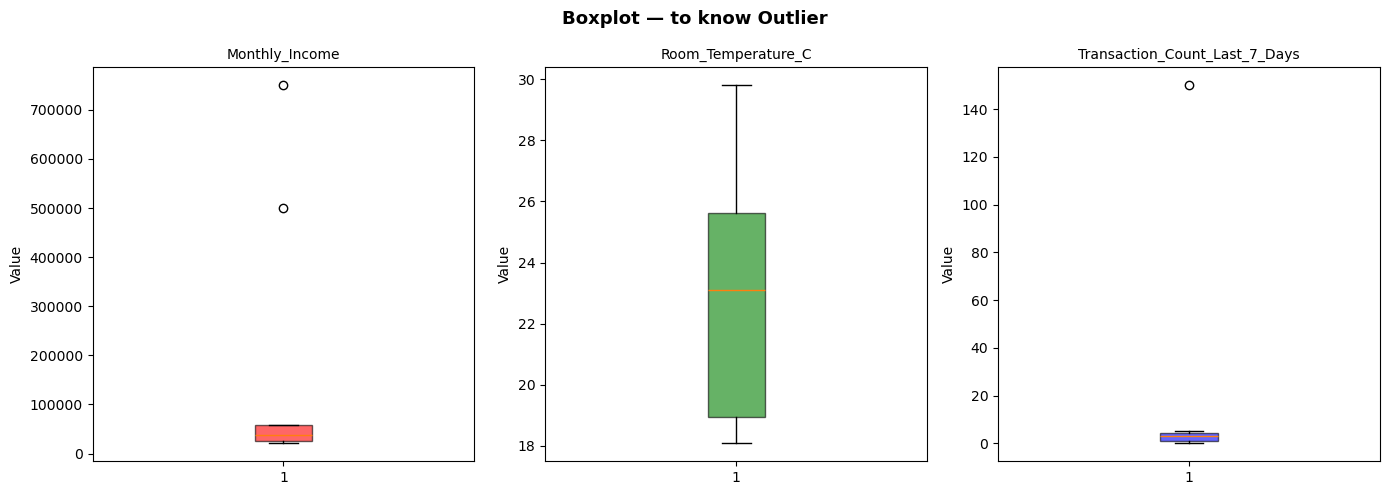

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

features = ['Monthly_Income', 'Room_Temperature_C', 'Transaction_Count_Last_7_Days']
colors = ['red', 'green', 'blue']

for axe, feature, color in zip(axes, features, colors):
    axe.boxplot(df[feature], patch_artist=True, boxprops=dict(facecolor=color, alpha=0.6))
    axe.set_title(feature, fontsize=10)
    axe.set_ylabel('Value')

plt.suptitle('Boxplot — to know Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


`boxplot`-এ box-এর বাইরে যে বিন্দু দেখা যায় সেগুলোই **outlier**।
- `Monthly_Income` → outlier আছে ✅
- `Room_Temperature_C` → outlier নেই ✅
- `Transaction_Count` → outlier আছে ✅


## Step 4: প্রতিটি Feature-এর জন্য সঠিক Scaler বেছে নেওয়া

| Feature | Scaler | কারণ |
|---|---|---|
| `Monthly_Income` | **Robust Scaler** | Outlier আছে — median ও IQR outlier-কে ignore করে |
| `Room_Temperature_C` | **Min-Max Scaler** | Bounded range (18–30), কোনো outlier নেই — [0,1]-এ সুন্দর আসবে |
| `Transaction_Count` | **Robust Scaler** | অনেক zero ও কিছু heavy outlier — Robust Scaler সেরা |


## Step 5: Scaling Apply করা

In [6]:
# প্রতিটি column 2D array-এ রূপান্তর করতে হয় (sklearn-এর requirement)
income      = df[['Monthly_Income']]
temperature = df[['Room_Temperature_C']]
transaction = df[['Transaction_Count_Last_7_Days']]

# Scaler তৈরি ও fit
robust_scaler   = RobustScaler()
minmax_scaler   = MinMaxScaler()

df['Income_Scaled']      = robust_scaler.fit_transform(income)
df['Temperature_Scaled'] = minmax_scaler.fit_transform(temperature)
df['Transaction_Scaled'] = robust_scaler.fit_transform(transaction)

df[['Monthly_Income',    'Income_Scaled',
    'Room_Temperature_C','Temperature_Scaled',
    'Transaction_Count_Last_7_Days','Transaction_Scaled']].head(20)


,Monthly_Income,Income_Scaled,Room_Temperature_C,Temperature_Scaled,Transaction_Count_Last_7_Days,Transaction_Scaled
0,35795,-0.045141,18.084796,0.000000,1,-0.615385
1,20860,-0.521936,18.276749,0.016387,3,0.000000
2,58158,0.668790,24.297296,0.530349,3,0.000000
3,31284,-0.189154,22.798332,0.402386,3,0.000000
4,26265,-0.349383,18.559988,0.040566,3,0.000000
5,36850,-0.011461,29.685066,0.990293,4,0.307692
6,57194,0.638014,20.793256,0.231216,2,-0.307692
7,41962,0.151738,19.087277,0.085580,5,0.615385
8,36023,-0.037863,25.420632,0.626247,0,-0.923077
9,21685,-0.495598,22.589544,0.384562,3,0.000000


`fit_transform()` একসাথে দুটো কাজ করে:
- **fit** → data দেখে median, IQR (বা min, max) শিখে নেয়।
- **transform** → সেই শেখা মান দিয়ে data scale করে।


## Step 6: Before vs After Scaling তুলনা

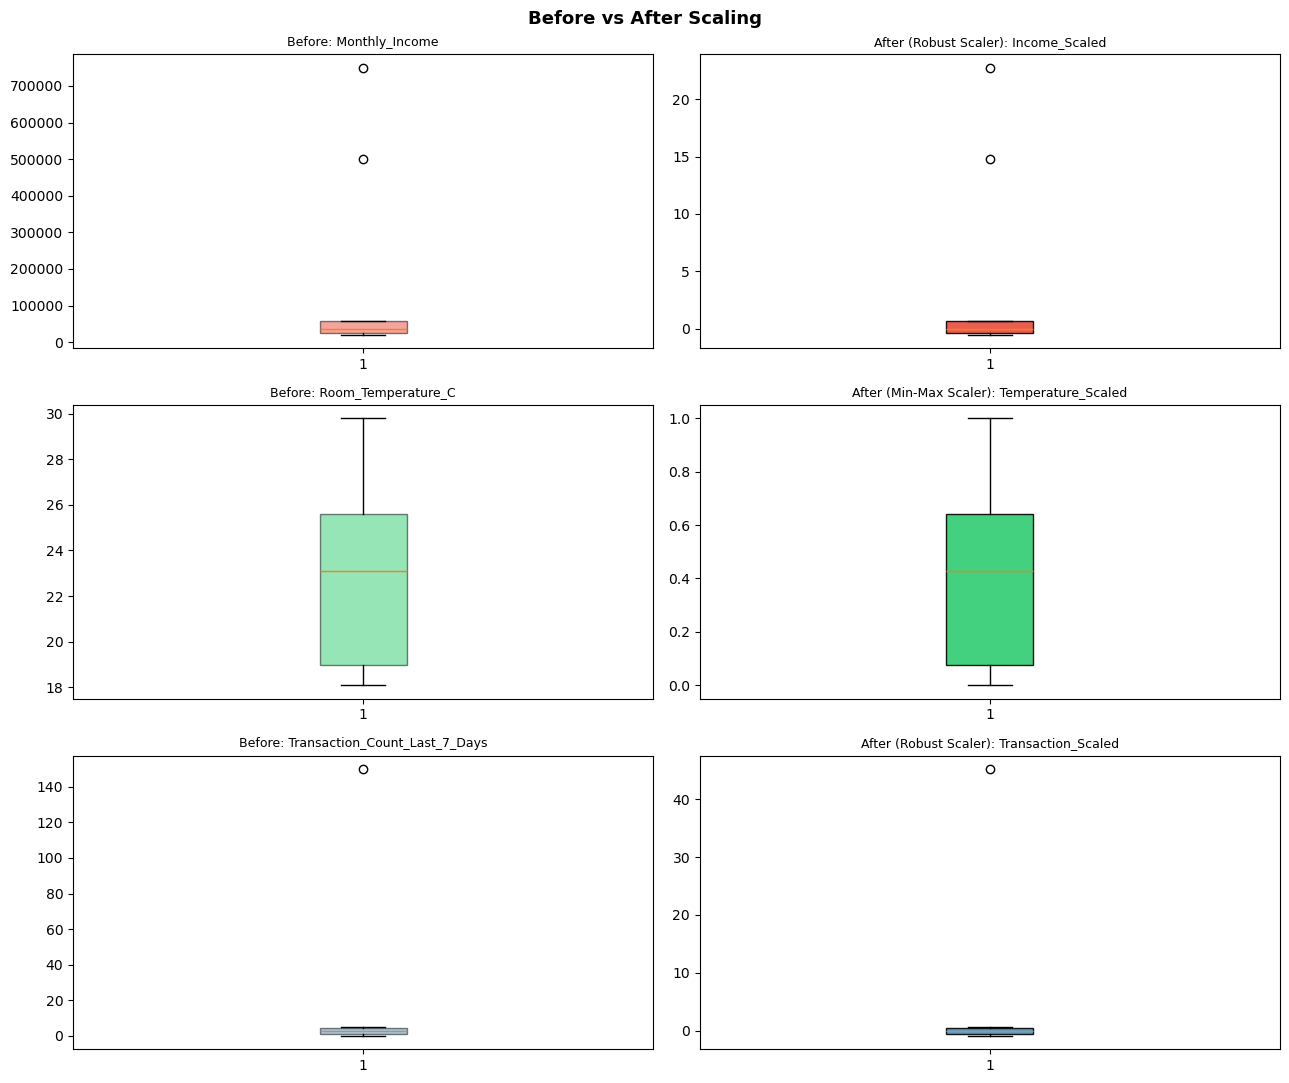

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

pairs = [
    ('Monthly_Income',               'Income_Scaled',       'Robust Scaler',   '#e74c3c'),
    ('Room_Temperature_C',           'Temperature_Scaled',  'Min-Max Scaler',  '#2ecc71'),
    ('Transaction_Count_Last_7_Days','Transaction_Scaled',  'Robust Scaler',   '#3498db'),
]

for i, (orig, scaled, scaler_name, color) in enumerate(pairs):
    # Before
    axes[i][0].boxplot(df[orig], patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.5))
    axes[i][0].set_title(f'Before: {orig}', fontsize=9)

    # After
    axes[i][1].boxplot(df[scaled], patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.9))
    axes[i][1].set_title(f'After ({scaler_name}): {scaled}', fontsize=9)

plt.suptitle('Before vs After Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Before** — প্রতিটি feature-এর নিজস্ব scale, outlier বড় ব্যবধান তৈরি করছে।

**After** — scaling-এর পরে feature-গুলো comparable scale-এ এসেছে।
Outlier-যুক্ত feature-গুলোতে **Robust Scaler** অন্য data-র shape ঠিক রেখেছে।


## Step 7: Quick Numeric Example — কেন এই Scaler নিরাপদ?

In [12]:
# ── Monthly_Income: Robust vs Min-Max তুলনা ──
sample_income = np.array([[20000],[35000],[50000],[500000]])

robust_out = RobustScaler().fit_transform(sample_income)
minmax_out = MinMaxScaler().fit_transform(sample_income)

print("Monthly_Income — Robust vs Min-Max:")
print(f"{'Value':>10} | {'Robust':>8} | {'Min-Max':>8}")
print("-" * 35)
for v, r, m in zip(sample_income.flatten(),
                   robust_out.flatten(),
                   minmax_out.flatten()):
    print(f"{v:>10,.0f} | {r:>8.3f} | {m:>8.3f}")

print()

# ── Room_Temperature_C: Min-Max ──
sample_temp = np.array([[18],[22],[26],[30]])
temp_scaled = MinMaxScaler().fit_transform(sample_temp)

print("Room_Temperature_C — Min-Max:")
print(f"{'Value':>8} | {'Scaled':>8}")
print("-" * 20)
for v, s in zip(sample_temp.flatten(), temp_scaled.flatten()):
    print(f"{v:>8.1f} | {s:>8.3f}")


Monthly_Income — Robust vs Min-Max:
     Value |   Robust |  Min-Max
-----------------------------------
    20,000 |   -0.171 |    0.000
    35,000 |   -0.057 |    0.031
    50,000 |    0.057 |    0.062
   500,000 |    3.486 |    1.000

Room_Temperature_C — Min-Max:
   Value |   Scaled
--------------------
    18.0 |    0.000
    22.0 |    0.333
    26.0 |    0.667
    30.0 |    1.000


**Monthly_Income-এ লক্ষ্য করো:**
- **Robust Scaler** → 20,000 থেকে 50,000-এর মানগুলো কাছাকাছি, 5,00,000 outlier দূরে — বাকি data ঠিক থাকে।
- **Min-Max Scaler** → 5,00,000 outlier-এর কারণে 20,000–50,000-এর সব মান 0-এর কাছে চাপা পড়ে যায়। এটি **বিপজ্জনক**।

**Room_Temperature_C-এ লক্ষ্য করো:**
- **Min-Max Scaler** → 18→0.0, 30→1.0 সুন্দরভাবে [0,1]-এ আসে। কোনো outlier না থাকায় এটি নিরাপদ।


---